In [2]:
# Load dependencies
import pandas as pd
import numpy as np

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px
import nbformat

In [3]:
# Read the dataset
chicago_taxi_dataframe = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

# updates daataframe to use specific columns.
training_df = chicago_taxi_dataframe.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]
training_df.head(200)

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [4]:
# View dataset statistics
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

# What is the maximum fare?
# max_fare = training_df['FARE'].max()
max_fare = training_df['FARE'].describe()['max']
print(f"What is the maximum fare?  Answer: ${max_fare:.2f}")


# What is the mean distance across all trips?
# mean_distance = training_df['TRIP_MILES'].mean()
mean_distance = training_df['TRIP_MILES'].describe()['mean']
print(f"What is the mean distance across all trips? Answer: {mean_distance:.4f}")

# How many cabs companies are in the dataset?
# num_unique_companies = len(training_df['COMPANY'].unique())
num_unique_companies = training_df['COMPANY'].describe()['unique']
print(f"How many cabs companies are in the dataset? Answer: {num_unique_companies}")


# What is the most frequent payment type?
# most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
most_freq_payment_type = training_df['PAYMENT_TYPE'].describe()['top']
print(f"What is the most frequent payment type? Answer: {most_freq_payment_type}")

# Are any feature missing data?
missing_values = training_df.isnull().sum().sum()
print(f"Are any feature missing data? Answer:", "No" if missing_values == 0 else "Yes")


Total number of rows: 31694


What is the maximum fare?  Answer: $159.25
What is the mean distance across all trips? Answer: 8.2895
How many cabs companies are in the dataset? Answer: 31
What is the most frequent payment type? Answer: Credit Card
Are any feature missing data? Answer: No


In [5]:
# View correlation matrix
print(training_df.corr(numeric_only=True))

              TRIP_MILES  TRIP_SECONDS      FARE  TIP_RATE
TRIP_MILES      1.000000      0.800855  0.975344 -0.049594
TRIP_SECONDS    0.800855      1.000000  0.830292 -0.084294
FARE            0.975344      0.830292  1.000000 -0.070979
TIP_RATE       -0.049594     -0.084294 -0.070979  1.000000


In [6]:
# View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])


In [7]:
# Train Model
# Define ML functions
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
    """Create and compile a simple linear regression model."""
    # Describe the topography of the model
    # The topography of a simple linear regression model
    # is a single node in a single layer.
    inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
    concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
    outputs = keras.layers.Dense(units=1)(concatenated_inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model topography into code that Keras can efficiently
    # execute. Configure training to minimize the model's mean squared error.
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
        loss="mean_squared_error",
        metrics=metrics
        )
    return model
def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
    ) -> ml_edu.experiment.Experiment:
    """Train the model by feeding it data"""
    features = {name: dataset[name].values for name in settings.input_features}
    label = dataset[label_name].values
    history = model.fit(
        x=features,
        y=label,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs
        )
    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history),
    )


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 433.1469 - rmse: 20.8122
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 191.7073 - rmse: 13.8458
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 55.1670 - rmse: 7.4275
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18.0635 - rmse: 4.2501
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 16.3131 - rmse: 4.0389
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 15.4082 - rmse: 3.9253
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.7745 - rmse: 3.8438
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.3908 - rmse: 3.7935
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.1961 - rmse: 3.7678
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.1005 - rmse: 3.7551
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.0590 - rmse: 3.7495
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.0460 - rmse: 3.74

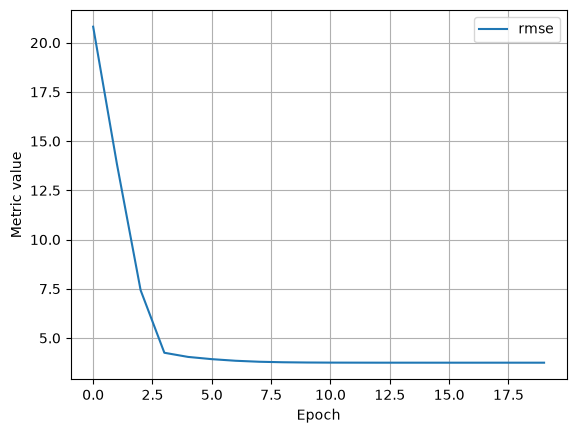

In [ ]:
# Experiment 1 (Train a model with single features)
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')
    


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 48.6203 - rmse: 6.9728
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 46.7570 - rmse: 6.8379
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.1339 - rmse: 6.9379
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.1349 - rmse: 6.9379
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 48.2322 - rmse: 6.9449
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.7817 - rmse: 6.9124
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 46.7843 - rmse: 6.8399
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 48.2919 - rmse: 6.9492
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 46.9870 - rmse: 6.8547
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.1217 - rmse: 6.8645
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.3996 - rmse: 6.9570
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 47.3138 - rmse: 6.8785
E

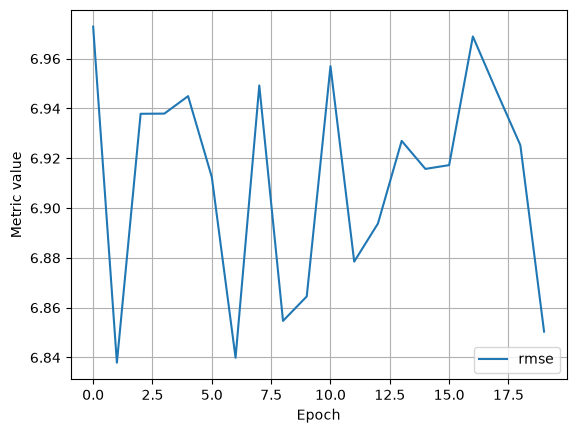

In [ ]:
# Experiment 2 (Experiment 1: Increase the learning rate to 1.0 (batch size at 50))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=1.0,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2032.7950 - rmse: 45.0865
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1967.8613 - rmse: 44.3606
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1903.7606 - rmse: 43.6321
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1840.5709 - rmse: 42.9019
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1778.5402 - rmse: 42.1727
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1717.7115 - rmse: 41.4453
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1657.7212 - rmse: 40.7151
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1598.8296 - rmse: 39.9854
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1541.0880 - rmse: 39.2567
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1484.4176 - rmse: 38.5281
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1428.9680 - rmse: 37.8017
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

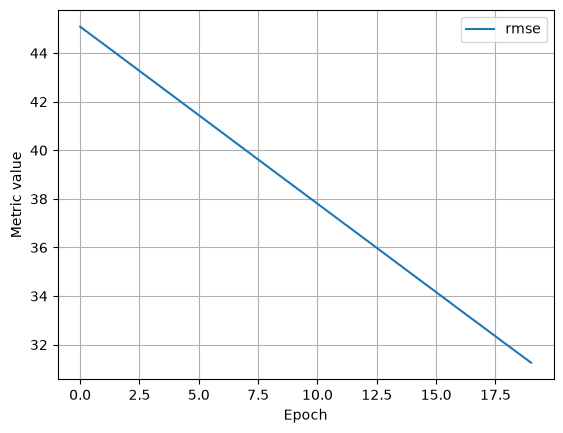

In [ ]:
# Experiment 2(Experiment 2: Decrease the learning rate to 0.0001 (batch size at 50)) 
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.0001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 985.7383 - rmse: 31.3965
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 938.8366 - rmse: 30.6404
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 893.8068 - rmse: 29.8966
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 849.9925 - rmse: 29.1546
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 807.1047 - rmse: 28.4096
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 765.4805 - rmse: 27.6673
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 724.9979 - rmse: 26.9258
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 685.6083 - rmse: 26.1841
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 647.3246 - rmse: 25.4426
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 610.2333 - rmse: 24.7029
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 574.3314 - rmse: 23.9652
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 539.3591 - rmse: 23.2241
E

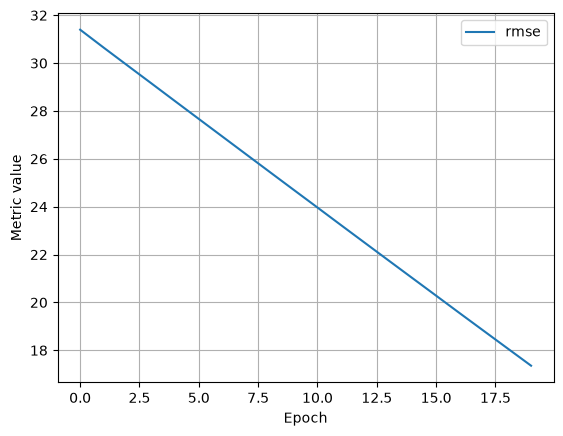

In [ ]:
# Experiment 2(Experiment 3: Increase the batch size to 500 (learning rate at 0.001))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=500,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2010964.1250 - rmse: 1418.0846
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 230993.4844 - rmse: 480.6178
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 93.6067 - rmse: 9.6751
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 92.9415 - rmse: 9.6406
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 92.9681 - rmse: 9.6420
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 92.5932 - rmse: 9.6225
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 92.3324 - rmse: 9.6090
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 91.9683 - rmse: 9.5900
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 91.9234 - rmse: 9.5877
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 92.0198 - rmse: 9.5927
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 91.7526 - rmse: 9.5788
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 91.9154 - 

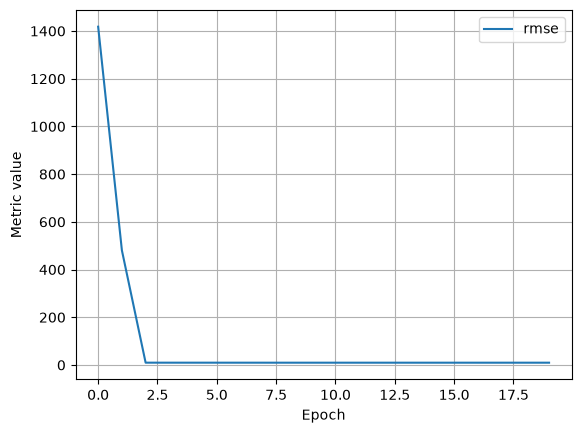

In [19]:
# Train a model with two features
# Experiment 3
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS'] / 60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_feature', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')